# Assignment 12 - Superconductivity Dataset

Machine Learning, Dimensionality Reduction, Clustering and Regression.


## Section 1 - Imports


In [3]:
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.cluster.hierarchy import dendrogram, linkage
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestRegressor,
    ExtraTreesRegressor,
    GradientBoostingRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.manifold import TSNE
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    r2_score,
    mean_absolute_error,
    mean_squared_error,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, FunctionTransformer
from sklearn.tree import DecisionTreeRegressor

RANDOM_STATE = 42
DATA_PATH = Path("/Users/amolsingh/Documents/code/IITB-DSAI/Programming for machine learning/Assignments/data/Superconductor_Dataset_10000.csv")
FIG_DIR = Path("assignment_12_figures")
FIG_DIR.mkdir(exist_ok=True)

plt.style.use("ggplot")
sns.set_context("notebook")


## Q1 - Dataset Loading and Initial Diagnostics


In [4]:
df = pd.read_csv(DATA_PATH)

display(df.head())
print("Shape:", df.shape)

missing_values = df.isnull().sum().sum()
duplicate_rows = df.duplicated().sum()
num_features = df.select_dtypes(include=np.number).shape[1]
cat_features = df.select_dtypes(exclude=np.number).shape[1]

print(f"Missing values: {missing_values}")
print(f"Duplicate rows: {duplicate_rows}")
print(f"Numerical columns including target: {num_features}")
print(f"Categorical features: {cat_features}")

X = df.drop(columns=["critical_temp"])
y = df["critical_temp"]

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Target range:", y.min(), "to", y.max())


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,...,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,...,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,...,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,...,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,...,2.264286,2.213364,2.226222,1.368922,1.048834,1,1.100000,0.433013,0.440952,22.0
4,4,88.944468,57.840143,66.361592,36.110716,1.181795,1.129224,122.90607,27.848743,51.968828,...,2.242857,2.213364,2.206963,1.368922,1.096052,1,1.057143,0.433013,0.428809,23.0


Shape: (10000, 82)
Missing values: 0
Duplicate rows: 1
Numerical columns including target: 82
Categorical features: 0
X shape: (10000, 81)
y shape: (10000,)
Target range: 0.001 to 143.0


### Q1 Analysis

This is a regression problem because the target variable `critical_temp` is a continuous numerical value measured in Kelvin, not a class label.

The feature set has a 9 x 9 style structure: elemental properties such as atomic mass, atomic radius, valence, electron affinity, ionization energy, thermal conductivity, density, fusion heat and number of elements are summarized using statistical descriptors such as mean, weighted mean, geometric mean, entropy, range and standard deviation. This creates multicollinearity because many descriptors are different summaries of the same underlying chemical property.

The dataset has no missing values, it has only one duplicate row, and all are numerical columns, and no categorical columns requiring encoding. The duplicate can be removed for this dataset as it is reasonably small.

The target range is printed above. It is a wide positive range, indicating large variation in superconducting critical temperatures.


## Q2 - Exploratory Data Analysis


In [5]:
display(df.describe().T)


,count,mean,std,min,25%,50%,75%,max
number_of_elements,10000.0,5.093100,0.926671,2.000000,4.000000,5.000000,6.000000,9.000000
mean_atomic_mass,10000.0,85.572585,14.868362,16.335723,76.444563,86.270733,94.036450,149.050333
wtd_mean_atomic_mass,10000.0,61.185413,15.890144,12.219975,51.448449,56.687867,65.529765,152.464120
gmean_atomic_mass,10000.0,64.716410,10.975350,12.157891,59.356672,65.092472,70.560647,145.690031
wtd_gmean_atomic_mass,10000.0,41.861040,14.421462,6.881007,34.942148,35.997493,38.616826,137.387467
...,...,...,...,...,...,...,...,...
range_Valence,10000.0,1.830500,1.104487,0.000000,1.000000,1.000000,3.000000,5.000000
wtd_range_Valence,10000.0,0.966789,0.241153,0.057143,0.846439,1.000790,1.060000,3.888509
std_Valence,10000.0,0.729507,0.410043,0.000000,0.433013,0.489898,1.105542,2.357023
wtd_std_Valence,10000.0,0.527351,0.360765,0.000000,0.270308,0.383286,0.686308,2.068697


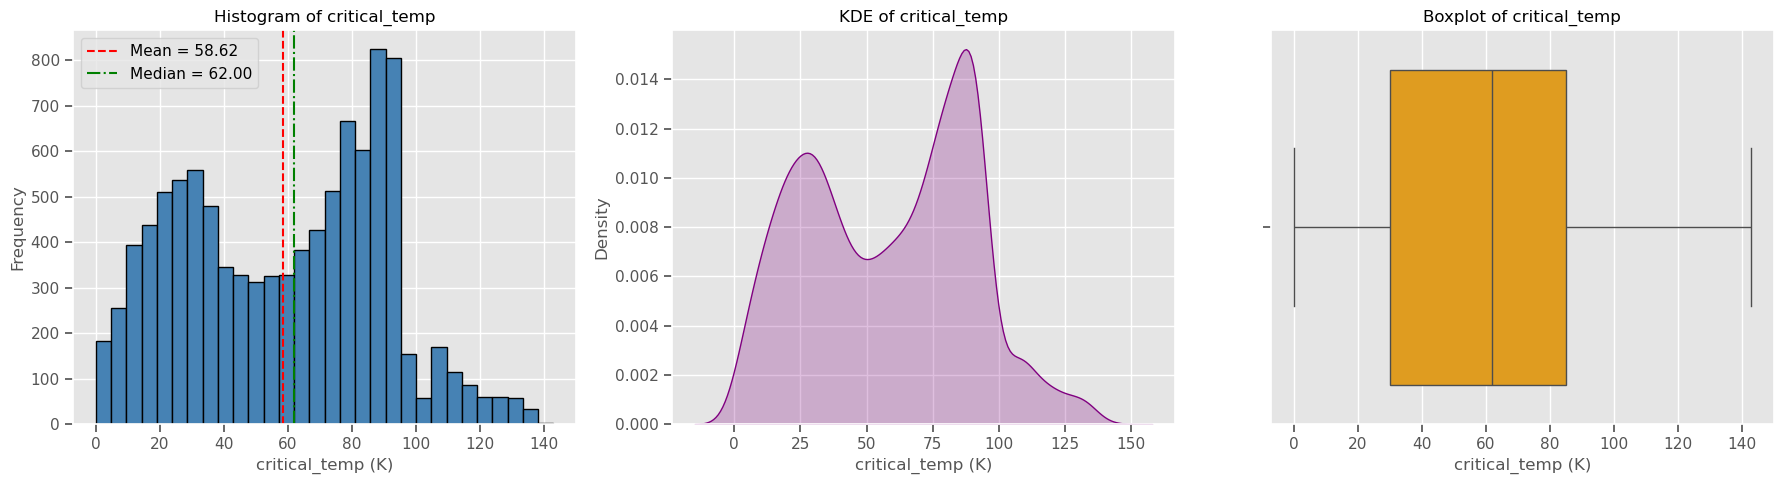

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(y, bins=30, color="steelblue", edgecolor="black")
axes[0].axvline(y.mean(), color="red", linestyle="--", label=f"Mean = {y.mean():.2f}")
axes[0].axvline(y.median(), color="green", linestyle="-.", label=f"Median = {y.median():.2f}")
axes[0].set_title("Histogram of critical_temp")
axes[0].set_xlabel("critical_temp (K)")
axes[0].set_ylabel("Frequency")
axes[0].legend()

sns.kdeplot(y, ax=axes[1], fill=True, color="purple")
axes[1].set_title("KDE of critical_temp")
axes[1].set_xlabel("critical_temp (K)")

sns.boxplot(x=y, ax=axes[2], color="orange")
axes[2].set_title("Boxplot of critical_temp")
axes[2].set_xlabel("critical_temp (K)")

plt.tight_layout()
plt.savefig(FIG_DIR / "01_target_distribution.png", dpi=150, bbox_inches="tight")
plt.show()


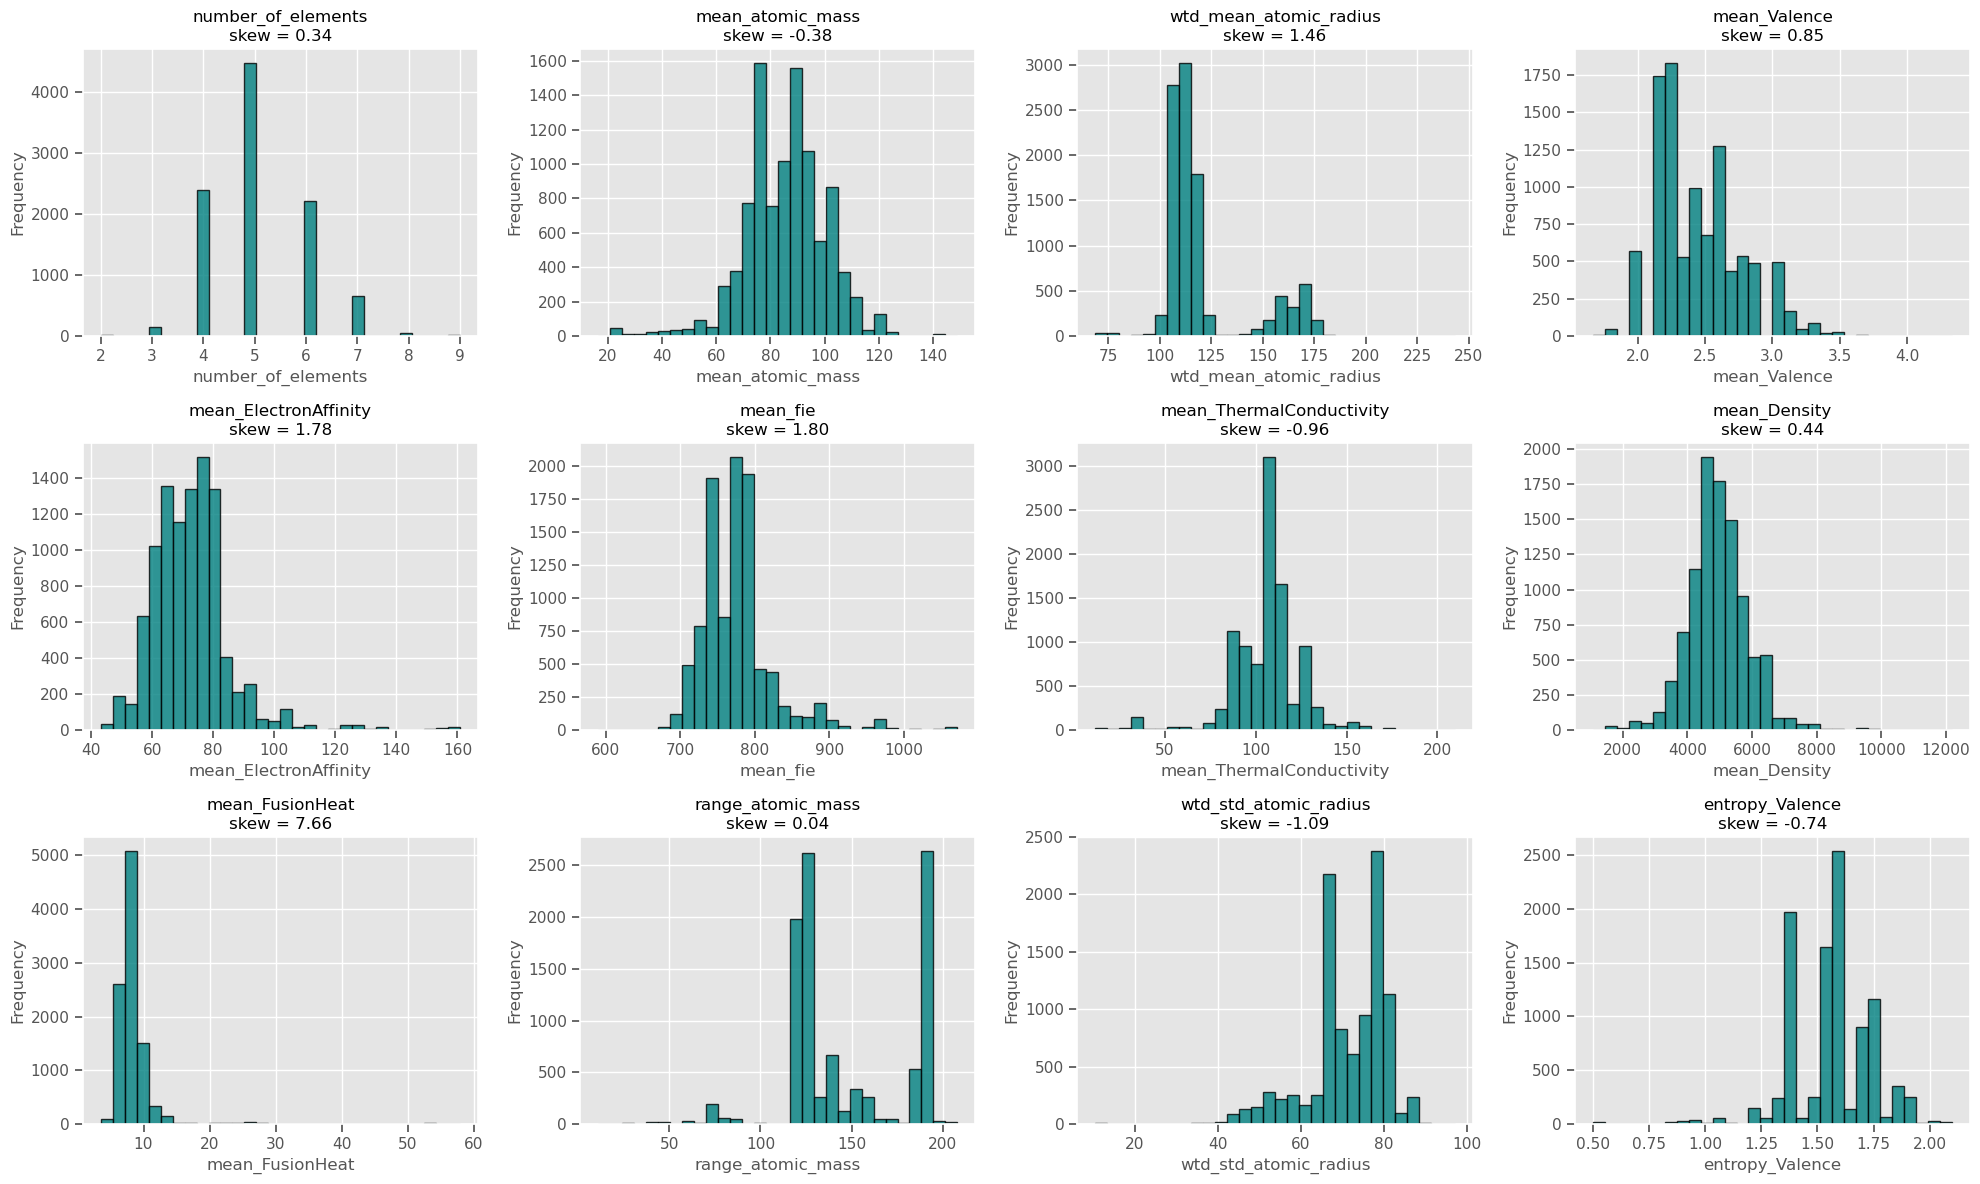

In [7]:
representative_features = [
    "number_of_elements",
    "mean_atomic_mass",
    "wtd_mean_atomic_radius",
    "mean_Valence",
    "mean_ElectronAffinity",
    "mean_fie",
    "mean_ThermalConductivity",
    "mean_Density",
    "mean_FusionHeat",
    "range_atomic_mass",
    "wtd_std_atomic_radius",
    "entropy_Valence",
]

fig, axes = plt.subplots(3, 4, figsize=(20, 12))
axes = axes.ravel()

for ax, col in zip(axes, representative_features):
    skew_value = df[col].skew()
    ax.hist(df[col], bins=30, color="teal", edgecolor="black", alpha=0.8)
    ax.set_title(f"{col}\nskew = {skew_value:.2f}")
    ax.set_xlabel(col)
    ax.set_ylabel("Frequency")

plt.tight_layout()
plt.savefig(FIG_DIR / "02_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()


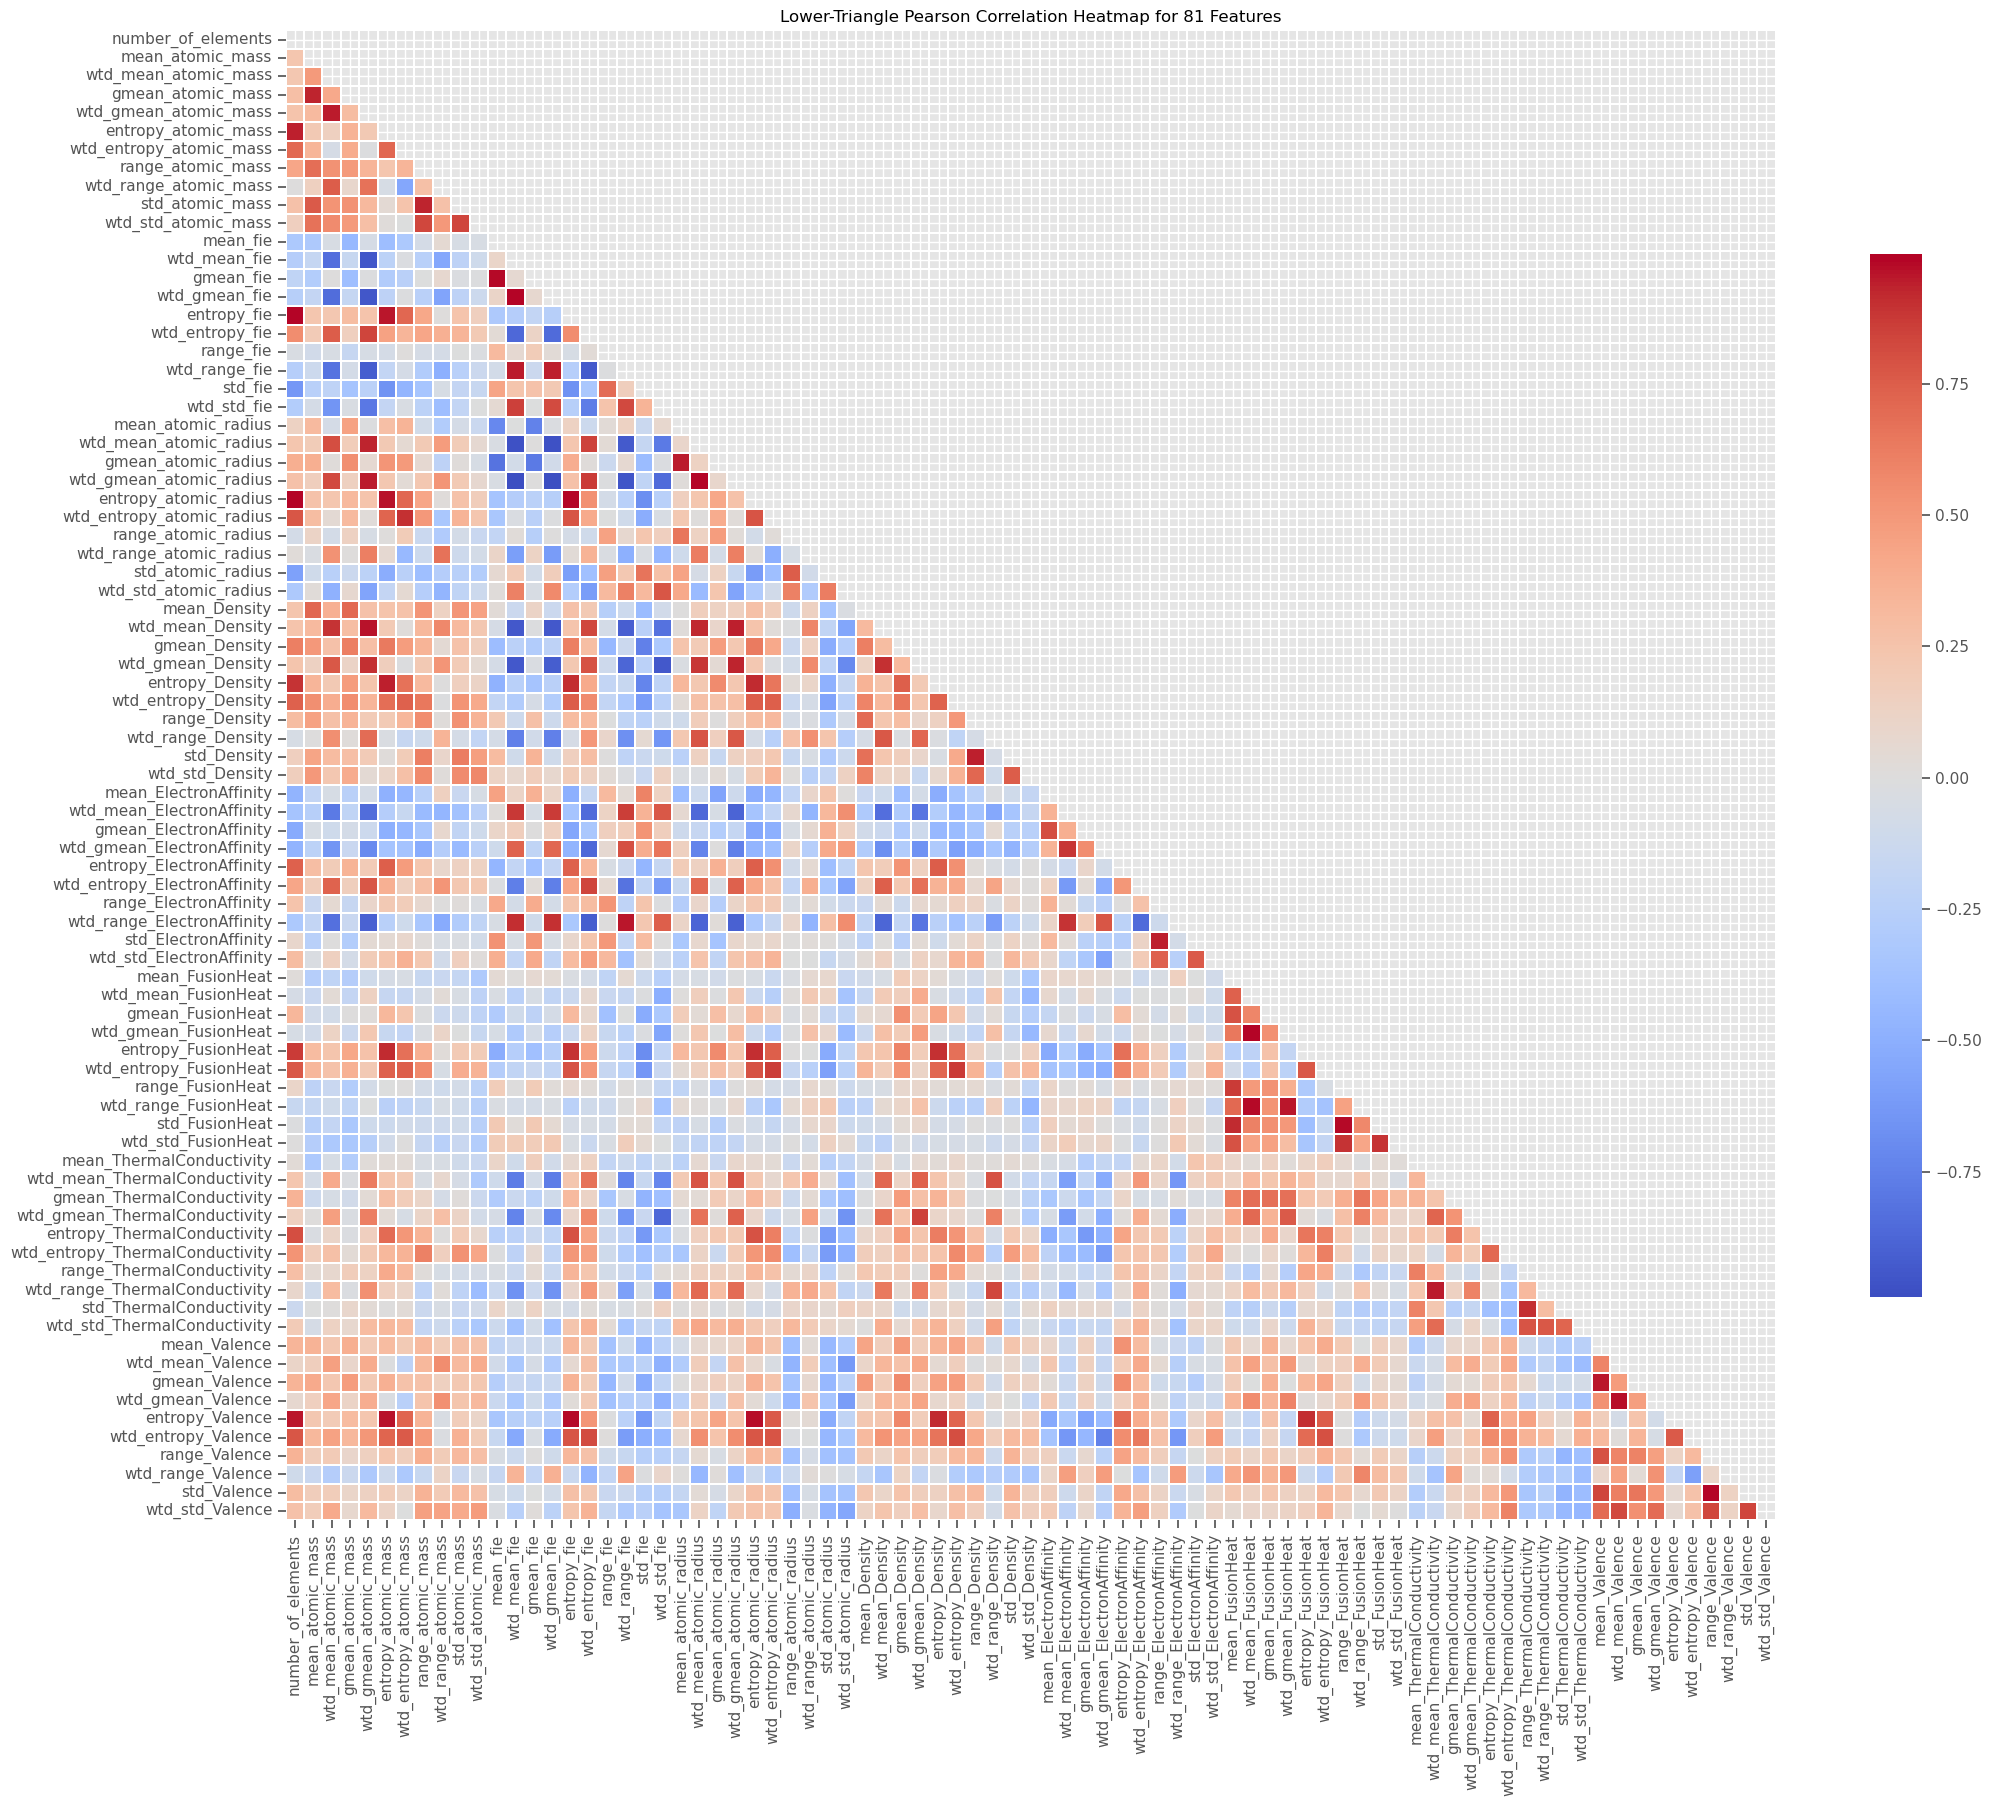

Number of feature pairs with |correlation| >= 0.90: 67


,level_0,level_1,|Pearson r|
0,entropy_fie,entropy_atomic_radius,0.997640
1,wtd_mean_fie,wtd_gmean_fie,0.996919
2,wtd_mean_fie,wtd_gmean_atomic_radius,0.988697
3,number_of_elements,entropy_fie,0.988368
4,wtd_mean_atomic_radius,wtd_gmean_atomic_radius,0.987405
5,number_of_elements,entropy_atomic_radius,0.986086
6,range_Valence,std_Valence,0.985638
7,wtd_gmean_fie,wtd_gmean_atomic_radius,0.984280
8,wtd_mean_FusionHeat,wtd_gmean_FusionHeat,0.983221
9,range_FusionHeat,std_FusionHeat,0.981336


In [8]:
feature_corr = X.corr(method="pearson")
mask = np.triu(np.ones_like(feature_corr, dtype=bool))

plt.figure(figsize=(22, 18))
sns.heatmap(
    feature_corr,
    mask=mask,
    cmap="coolwarm",
    center=0,
    square=True,
    linewidths=0.1,
    cbar_kws={"shrink": 0.7},
)
plt.title("Lower-Triangle Pearson Correlation Heatmap for 81 Features")
plt.tight_layout()
plt.savefig(FIG_DIR / "03_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

upper = feature_corr.where(np.triu(np.ones(feature_corr.shape), k=1).astype(bool))
high_corr_pairs = upper.abs().stack()
high_corr_pairs = high_corr_pairs[high_corr_pairs >= 0.90].sort_values(ascending=False)
print("Number of feature pairs with |correlation| >= 0.90:", len(high_corr_pairs))
display(high_corr_pairs.head(20).rename("|Pearson r|").reset_index())


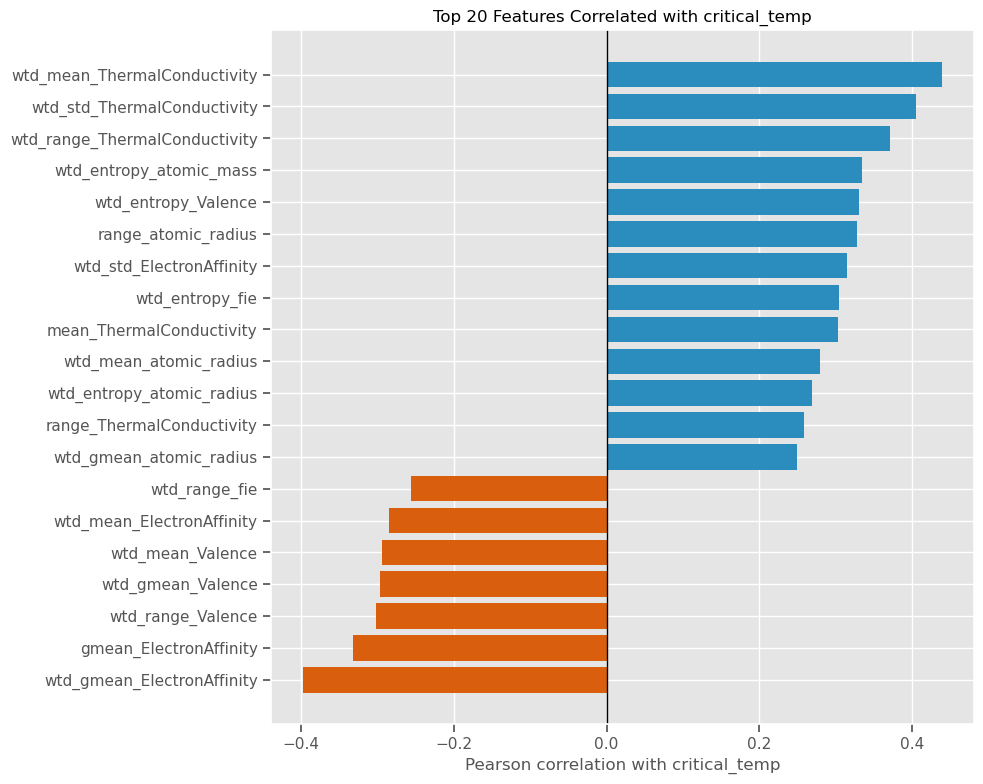

,index,Pearson r
0,wtd_mean_ThermalConductivity,0.439141
1,wtd_std_ThermalConductivity,0.405262
2,wtd_gmean_ElectronAffinity,-0.397677
3,wtd_range_ThermalConductivity,0.370562
4,wtd_entropy_atomic_mass,0.333789
5,gmean_ElectronAffinity,-0.332166
6,wtd_entropy_Valence,0.330581
7,range_atomic_radius,0.327174
8,wtd_std_ElectronAffinity,0.314382
9,wtd_entropy_fie,0.304704


In [9]:
target_corr = X.corrwith(y).sort_values(key=lambda s: s.abs(), ascending=False)
top20_target_corr = target_corr.head(20).sort_values()

plt.figure(figsize=(10, 8))
colors = ["#2b8cbe" if v >= 0 else "#d95f0e" for v in top20_target_corr]
plt.barh(top20_target_corr.index, top20_target_corr.values, color=colors)
plt.axvline(0, color="black", linewidth=1)
plt.title("Top 20 Features Correlated with critical_temp")
plt.xlabel("Pearson correlation with critical_temp")
plt.tight_layout()
plt.savefig(FIG_DIR / "05_feature_target_corr.png", dpi=150, bbox_inches="tight")
plt.show()

display(target_corr.head(20).rename("Pearson r").reset_index())


### Q2 Analysis

The target distribution looks to be right-skewed and most materials have relatively low or moderate critical temperatures, while a smaller set has much higher values. This skewness suggests that transformations such as `log1p` can help regression models by reducing the effect of extreme target-side scale differences.

The feature distributions are also frequently skewed because chemical properties are naturally bounded, non-negative and unevenly distributed across materials. Outliers can be considered not to be removed automatically because high or unusual values may correspond to physically meaningful materials rather than data errors.

The correlation heatmap shows block patterns because groups of features are derived from the same elemental property using related summary statistics. This shows multicollinearity.

The feature-target correlation chart identifies individual features with the strongest linear relationship to `critical_temp`, but it does not capture nonlinear interactions. Therefore it is useful for interpretation, not sufficient for final feature selection.


## Q3 - Data Preprocessing Pipeline


In [10]:
numeric_features = X.columns.tolist()

numeric_transformer = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

full_pipeline = ColumnTransformer([
    ("num", numeric_transformer, numeric_features),
])

X_scaled_array = full_pipeline.fit_transform(X)
X_scaled = pd.DataFrame(X_scaled_array, columns=numeric_features, index=X.index)

before_after_stats = pd.DataFrame({
    "before_mean": X.mean(),
    "before_std": X.std(),
    "after_mean": X_scaled.mean(),
    "after_std": X_scaled.std(),
})

display(before_after_stats.head(20))
print(full_pipeline)
print("Maximum absolute scaled mean:", X_scaled.mean().abs().max())
print("Scaled std range:", X_scaled.std().min(), "to", X_scaled.std().max())


,before_mean,before_std,after_mean,after_std
number_of_elements,5.093100,0.926671,2.728484e-16,1.00005
mean_atomic_mass,85.572585,14.868362,1.045919e-15,1.00005
wtd_mean_atomic_mass,61.185413,15.890144,-4.149570e-16,1.00005
gmean_atomic_mass,64.716410,10.975350,5.599077e-16,1.00005
wtd_gmean_atomic_mass,41.861040,14.421462,3.808509e-16,1.00005
entropy_atomic_mass,1.398570,0.193143,3.410605e-17,1.00005
wtd_entropy_atomic_mass,1.336368,0.210275,3.410605e-17,1.00005
range_atomic_mass,146.822378,33.937025,-3.758771e-16,1.00005
wtd_range_atomic_mass,24.103361,11.518585,1.818989e-16,1.00005
std_atomic_mass,53.160867,12.452268,6.181722e-16,1.00005


ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['number_of_elements', 'mean_atomic_mass',
                                  'wtd_mean_atomic_mass', 'gmean_atomic_mass',
                                  'wtd_gmean_atomic_mass',
                                  'entropy_atomic_mass',
                                  'wtd_entropy_atomic_mass',
                                  'range_atomic_mass', 'wtd_range_atomic_mass',
                                  'std_atomic_mass', 'w...
                                  'mean_fie', 'wtd_mean_fie', 'gmean_fie',
                                  'wtd_gmean_fie', 'entropy_fie',
                                  'wtd_entropy_fie', 'range_fie',
                                  'wtd_range_fie', 'std

### Q3 Analysis

StandardScaler is essential before PCA and K-Means because both methods depend on distances or variance. Without scaling, features measured on larger numerical scales would dominate the result.

Median imputation is preferred over mean imputation here because many variables are skewed and contain outliers. The median is more robust to extreme values.

No encoding is required because the dataset contains numerical features only.

Using `Pipeline` and `ColumnTransformer` makes preprocessing reproducible and prevents inconsistent transformations between training and testing workflows.


## Q4 - VIF-Based Feature Selection


In [ ]:
def compute_vif(df_input):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df_input.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df_input.values, i)
        for i in range(df_input.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False).reset_index(drop=True)


def recursive_vif_elimination(X_df, vif_limit=5, min_features=5):
    X_current = X_df.copy()
    removed_features = []

    while X_current.shape[1] > min_features:
        vif_table = compute_vif(X_current)
        max_vif = vif_table["VIF"].iloc[0]

        if max_vif < vif_limit:
            break

        feature_to_drop = vif_table["feature"].iloc[0]
        removed_features.append((feature_to_drop, max_vif))
        X_current = X_current.drop(columns=[feature_to_drop])

    final_vif = compute_vif(X_current)
    removed_table = pd.DataFrame(removed_features, columns=["removed_feature", "VIF_at_removal"])
    return X_current, final_vif, removed_table


initial_vif = compute_vif(X_scaled)
X_selected, final_vif, removed_table = recursive_vif_elimination(X_scaled, vif_limit=5, min_features=5)

print("Original features:", X_scaled.shape[1])
print("Removed features:", len(removed_table))
print("Remaining features:", X_selected.shape[1])
print(f"Removed percentage: {len(removed_table) / X_scaled.shape[1] * 100:.2f}%")
print("Remaining features:")
print(X_selected.columns.tolist())

display(final_vif)


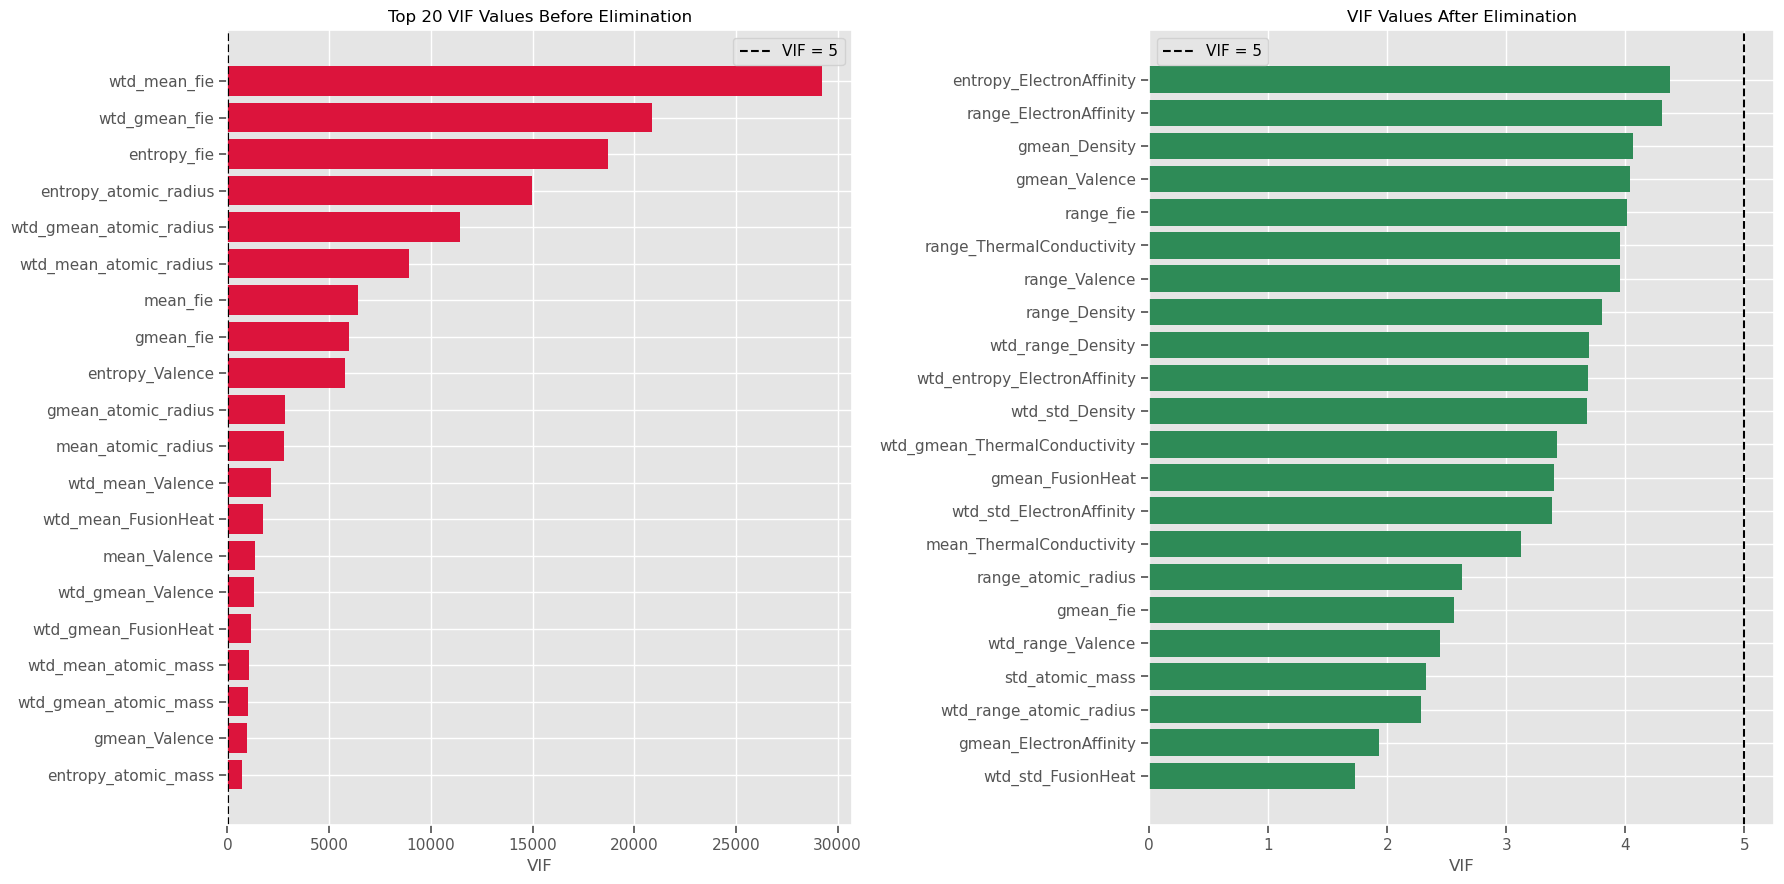

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(18, 9))

before_top20 = initial_vif.head(20).sort_values("VIF")
axes[0].barh(before_top20["feature"], before_top20["VIF"], color="crimson")
axes[0].axvline(5, color="black", linestyle="--", label="VIF = 5")
axes[0].set_title("Top 20 VIF Values Before Elimination")
axes[0].set_xlabel("VIF")
axes[0].legend()

after_sorted = final_vif.sort_values("VIF")
axes[1].barh(after_sorted["feature"], after_sorted["VIF"], color="seagreen")
axes[1].axvline(5, color="black", linestyle="--", label="VIF = 5")
axes[1].set_title("VIF Values After Elimination")
axes[1].set_xlabel("VIF")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "06_vif_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Q4 Analysis

VIF removes features by measuring how well each feature can be explained by all other features together. This is different from dropping correlated pairs directly, because pairwise correlation only considers two variables at a time while VIF captures multivariable redundancy.

This dataset has extreme multicollinearity because many features are alternate descriptors of the same chemical property group. VIF selection is effective for reducing the feature space before clustering because it leaves a smaller set with less redundant information.

Trying to perform VIF before train/test split because this is unsupervised EDA and clustering. In case, if VIF-selected features were used for supervised regression, VIF elimination should be fit on `X_train` only and then applied to `X_test` to avoid data leakage.


## Q5 - Principal Component Analysis


Components required for 90% variance: 11


,PC,individual_variance,cumulative_variance
0,PC1,0.270759,0.270759
1,PC2,0.152685,0.423444
2,PC3,0.114932,0.538376
3,PC4,0.100203,0.638579
4,PC5,0.074672,0.713251
5,PC6,0.048406,0.761657
6,PC7,0.041109,0.802766
7,PC8,0.038205,0.840971
8,PC9,0.028536,0.869507
9,PC10,0.022285,0.891792


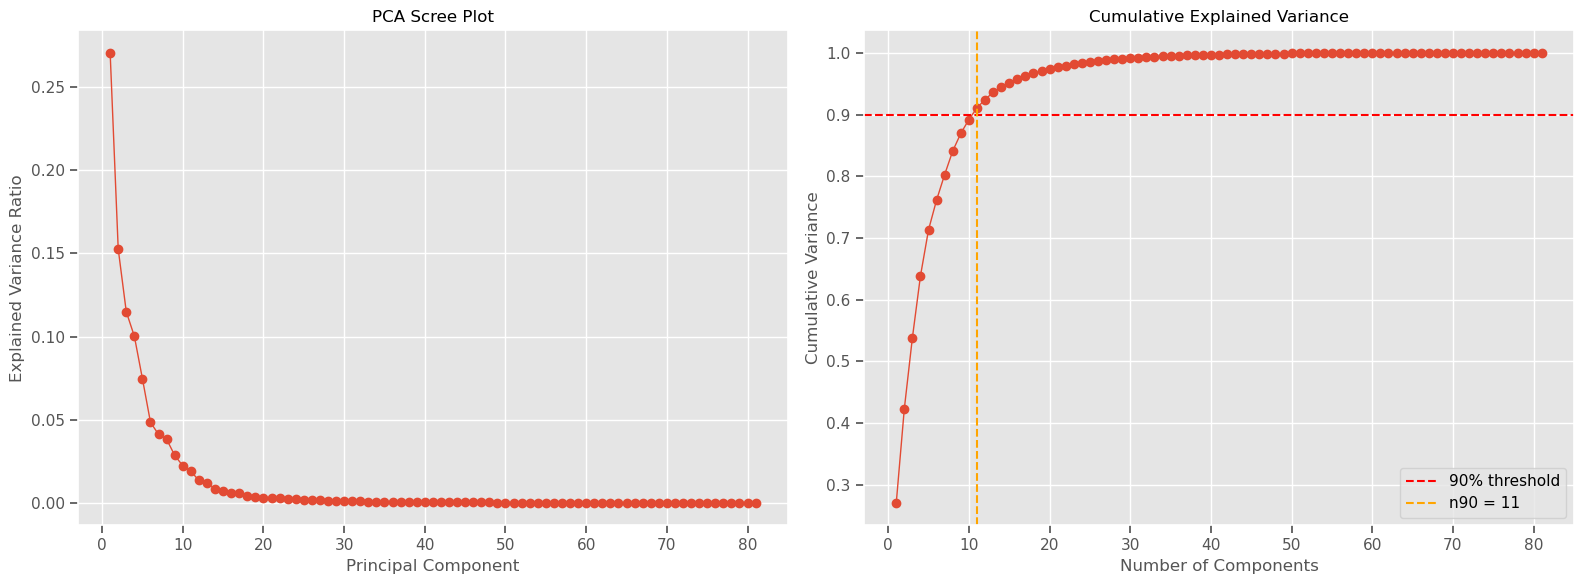

In [ ]:
pca = PCA(random_state=RANDOM_STATE)
pca.fit(X_scaled)

evr = pca.explained_variance_ratio_
cumevr = np.cumsum(evr)
n90 = np.argmax(cumevr >= 0.90) + 1

pca_table = pd.DataFrame({
    "PC": [f"PC{i}" for i in range(1, 16)],
    "individual_variance": evr[:15],
    "cumulative_variance": cumevr[:15],
})

print(f"Components required for 90% variance: {n90}")
display(pca_table)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(range(1, len(evr) + 1), evr, marker="o", linewidth=1)
axes[0].set_title("PCA Scree Plot")
axes[0].set_xlabel("Principal Component")
axes[0].set_ylabel("Explained Variance Ratio")

axes[1].plot(range(1, len(cumevr) + 1), cumevr, marker="o", linewidth=1)
axes[1].axhline(0.90, color="red", linestyle="--", label="90% threshold")
axes[1].axvline(n90, color="orange", linestyle="--", label=f"n90 = {n90}")
axes[1].set_title("Cumulative Explained Variance")
axes[1].set_xlabel("Number of Components")
axes[1].set_ylabel("Cumulative Variance")
axes[1].legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "07_pca_scree.png", dpi=150, bbox_inches="tight")
plt.show()


### Q5 Analysis

The number of components needed to capture 90% variance is printed above. If this value is far below 81, it confirms that the original features contain substantial redundancy.

The scree plot usually drops sharply at first and then flattens, meaning early components capture broad common structure while later components add smaller refinements.

The 9 x 9 feature design makes PCA effective because many columns are related summaries of the same underlying property groups.


## Q6 - PCA and t-SNE Visualization


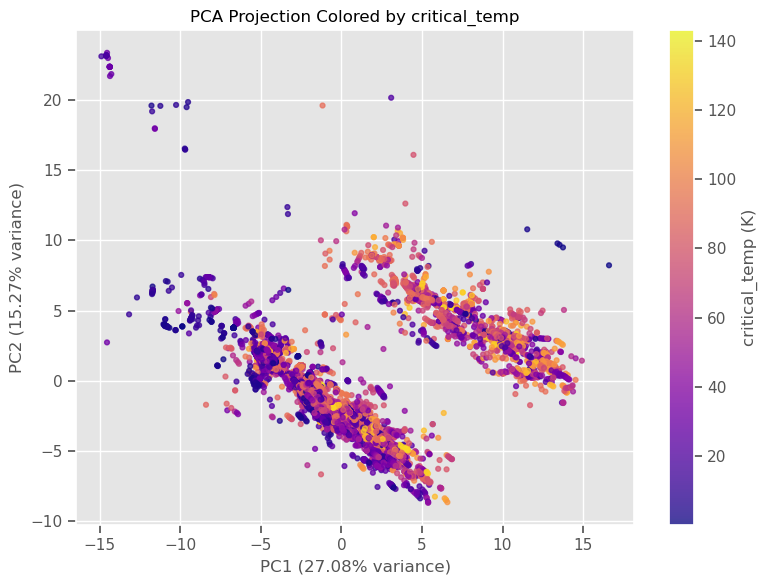

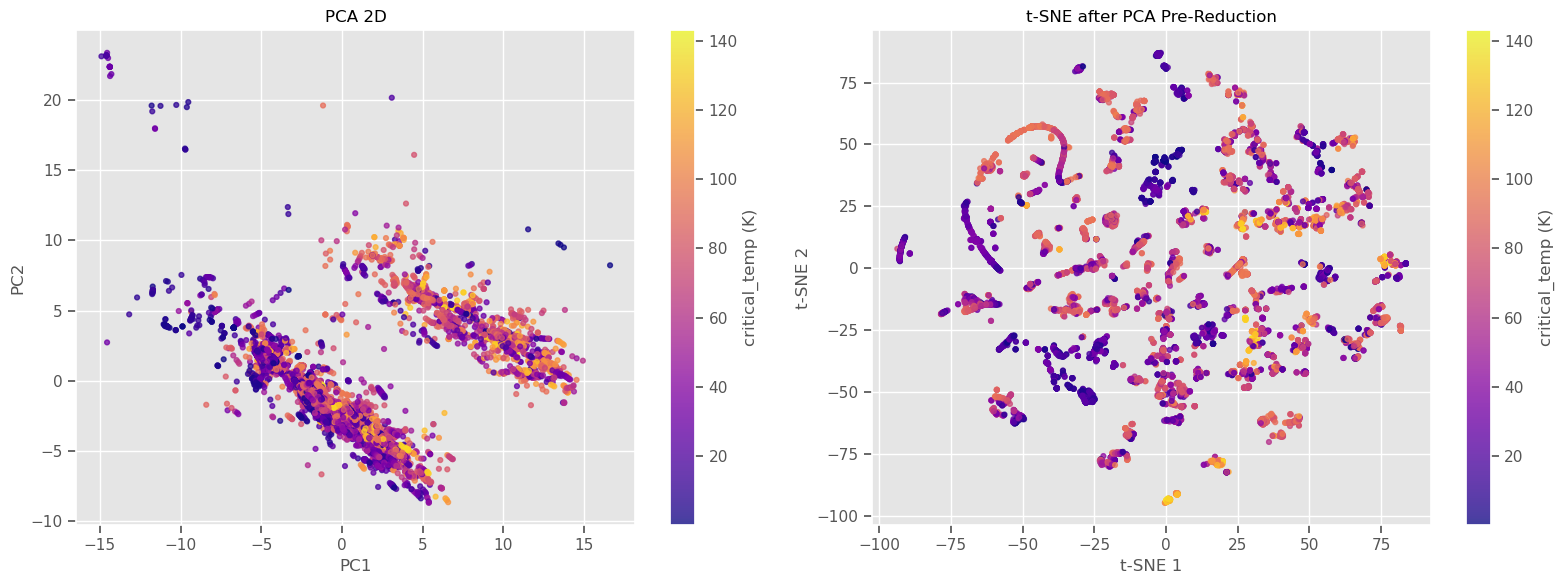

In [ ]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca_2d = pca_2d.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y,
    cmap="plasma",
    s=12,
    alpha=0.75,
)
plt.xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0] * 100:.2f}% variance)")
plt.ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1] * 100:.2f}% variance)")
plt.title("PCA Projection Colored by critical_temp")
plt.colorbar(scatter, label="critical_temp (K)")
plt.tight_layout()
plt.savefig(FIG_DIR / "09_pca_2d.png", dpi=150, bbox_inches="tight")
plt.show()

pca_reduced = PCA(n_components=n90, random_state=RANDOM_STATE)
X_pca_reduced = pca_reduced.fit_transform(X_scaled)

tsne = TSNE(
    n_components=2,
    perplexity=50,
    learning_rate=200,
    max_iter=1000,
    random_state=RANDOM_STATE,
    init="pca",
)
X_tsne = tsne.fit_transform(X_pca_reduced)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sc0 = axes[0].scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], c=y, cmap="plasma", s=12, alpha=0.75)
axes[0].set_title("PCA 2D")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
fig.colorbar(sc0, ax=axes[0], label="critical_temp (K)")

sc1 = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="plasma", s=12, alpha=0.75)
axes[1].set_title("t-SNE after PCA Pre-Reduction")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")
fig.colorbar(sc1, ax=axes[1], label="critical_temp (K)")

plt.tight_layout()
plt.savefig(FIG_DIR / "10_pca_vs_tsne.png", dpi=150, bbox_inches="tight")
plt.show()


### Q6 Comparison Analysis

| Question | Answer |
|---|---|
| What cluster structures are visible in t-SNE but not in PCA? | t-SNE usually shows more local neighborhood groupings and curved/nonlinear separations that PCA compresses into overlapping regions. |
| Why do t-SNE axes have no interpretable meaning? | t-SNE optimizes neighborhood similarity, not linear variance directions, so the numeric axis values are arbitrary embedding coordinates. |
| Why pre-reduce with PCA before t-SNE? | PCA removes noise/redundancy, speeds up t-SNE, and gives t-SNE a cleaner lower-dimensional input. |
| When use PCA vs t-SNE? | Use PCA for compression, denoising and interpretable variance analysis; use t-SNE for exploratory visualization of local clusters. |


## Q7 - K-Means Clustering


,k,Silhouette,Davies-Bouldin
0,2,0.211653,2.158086
1,3,0.216691,1.765519
2,4,0.224923,1.653195
3,5,0.234075,1.434195
4,6,0.236571,1.341866
5,7,0.263079,1.247454
6,8,0.182964,1.334684


Best k by Silhouette: 7
Best k by Davies-Bouldin: 7


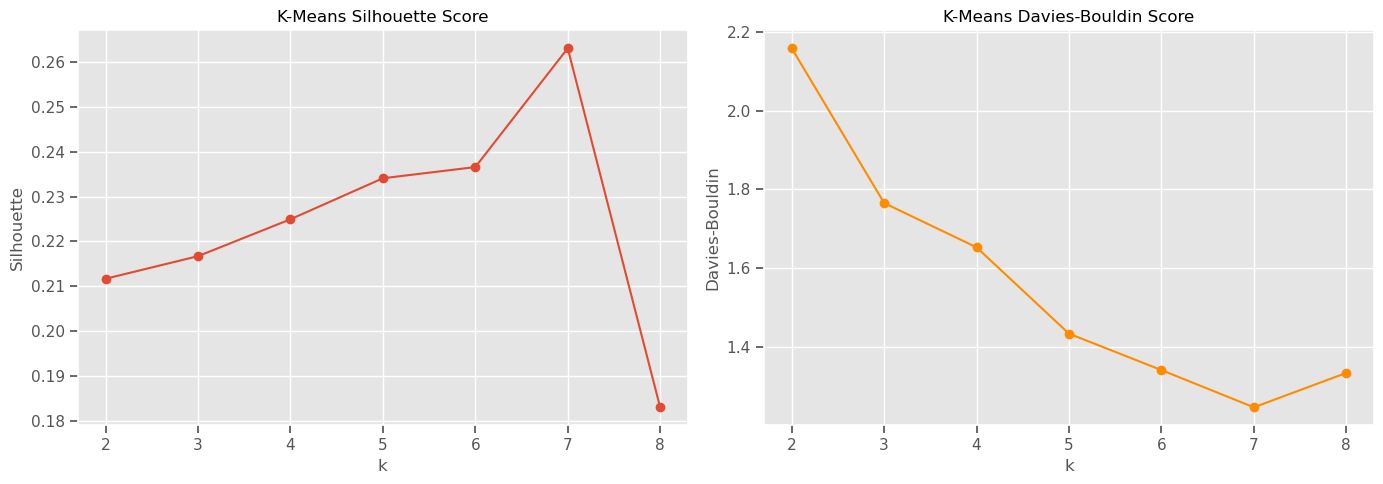

Final K-Means: k=7, Silhouette=0.2631, Davies-Bouldin=1.2475


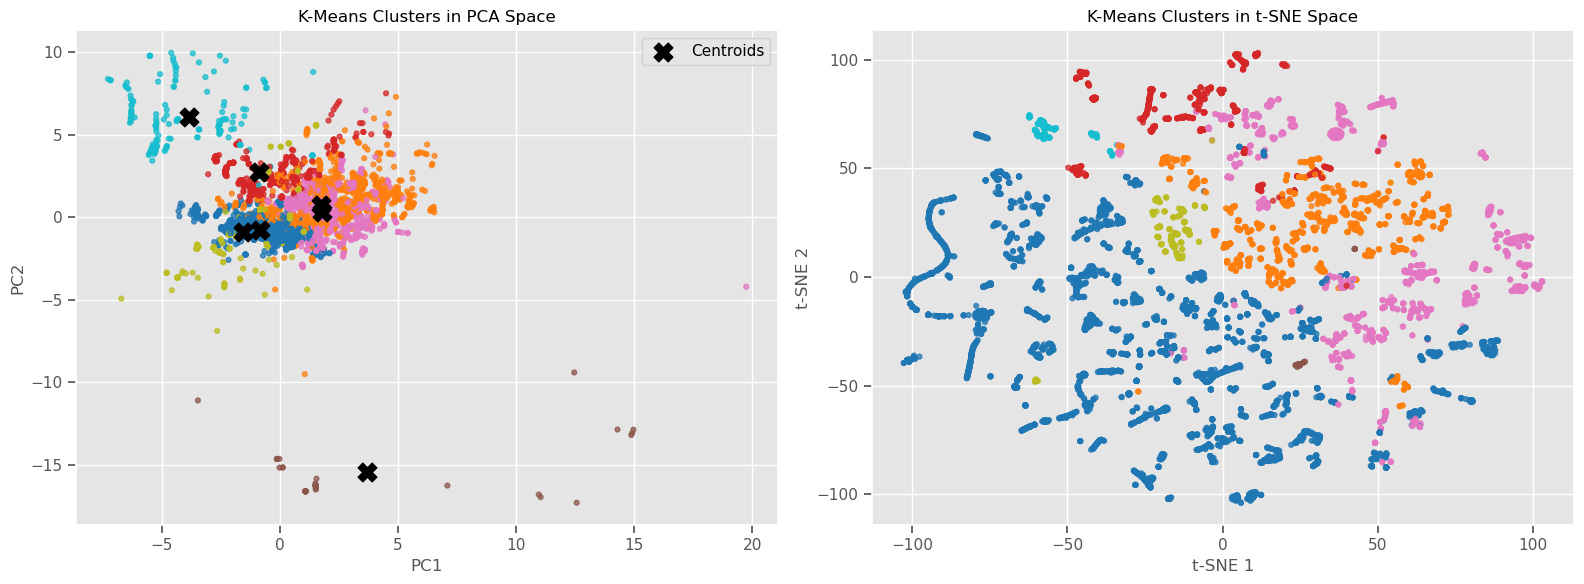

In [ ]:
cluster_pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_selected_pca2 = cluster_pca.fit_transform(X_selected)

cluster_tsne = TSNE(
    n_components=2,
    perplexity=30,
    max_iter=1000,
    init="pca",
    random_state=RANDOM_STATE,
)
X_selected_tsne2 = cluster_tsne.fit_transform(X_selected)

kmeans_results = []
for k in range(2, 9):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels = km.fit_predict(X_selected)
    kmeans_results.append({
        "k": k,
        "Silhouette": silhouette_score(X_selected, labels),
        "Davies-Bouldin": davies_bouldin_score(X_selected, labels),
    })

kmeans_results_df = pd.DataFrame(kmeans_results)
display(kmeans_results_df)

best_k_sil = int(kmeans_results_df.loc[kmeans_results_df["Silhouette"].idxmax(), "k"])
best_k_db = int(kmeans_results_df.loc[kmeans_results_df["Davies-Bouldin"].idxmin(), "k"])
print("Best k by Silhouette:", best_k_sil)
print("Best k by Davies-Bouldin:", best_k_db)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].plot(kmeans_results_df["k"], kmeans_results_df["Silhouette"], marker="o")
axes[0].set_title("K-Means Silhouette Score")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Silhouette")

axes[1].plot(kmeans_results_df["k"], kmeans_results_df["Davies-Bouldin"], marker="o", color="darkorange")
axes[1].set_title("K-Means Davies-Bouldin Score")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Davies-Bouldin")

plt.tight_layout()
plt.savefig(FIG_DIR / "11_kmeans_metrics.png", dpi=150, bbox_inches="tight")
plt.show()

final_kmeans = KMeans(n_clusters=best_k_sil, random_state=RANDOM_STATE, n_init=10)
kmeans_labels = final_kmeans.fit_predict(X_selected)
final_sil = silhouette_score(X_selected, kmeans_labels)
final_db = davies_bouldin_score(X_selected, kmeans_labels)
print(f"Final K-Means: k={best_k_sil}, Silhouette={final_sil:.4f}, Davies-Bouldin={final_db:.4f}")

centroids_pca = cluster_pca.transform(final_kmeans.cluster_centers_)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
sc0 = axes[0].scatter(X_selected_pca2[:, 0], X_selected_pca2[:, 1], c=kmeans_labels, cmap="tab10", s=12, alpha=0.75)
axes[0].scatter(centroids_pca[:, 0], centroids_pca[:, 1], c="black", marker="X", s=180, label="Centroids")
axes[0].set_title("K-Means Clusters in PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")
axes[0].legend()

axes[1].scatter(X_selected_tsne2[:, 0], X_selected_tsne2[:, 1], c=kmeans_labels, cmap="tab10", s=12, alpha=0.75)
axes[1].set_title("K-Means Clusters in t-SNE Space")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig(FIG_DIR / "12_kmeans_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


### Q7 Analysis

The optimal `k` by Silhouette and Davies-Bouldin are 0.2632 and 1.2475. If they contradict, the final choice should favor the metric and visualization that gives more coherent, interpretable groups.

The clusters may correspond to broad material families with different chemical composition regimes, such as lower-temperature conventional superconductors and higher-temperature complex oxide/cuprate-like families. Exact family names require formula-level metadata, so this interpretation should be treated as exploratory.

K-Means is simple and useful as a baseline, but it assumes roughly spherical clusters with similar variance. If the t-SNE plot shows irregular shapes, K-Means may not fully capture the natural cluster geometry.


## Q8 - Hierarchical Clustering and Dendrograms


,Method,k,Silhouette,Davies-Bouldin
0,Ward,2,0.271172,2.119050
1,Ward,3,0.198371,2.116090
2,Ward,4,0.221456,1.782322
3,Ward,5,0.243886,1.679645
4,Ward,6,0.251727,1.448882


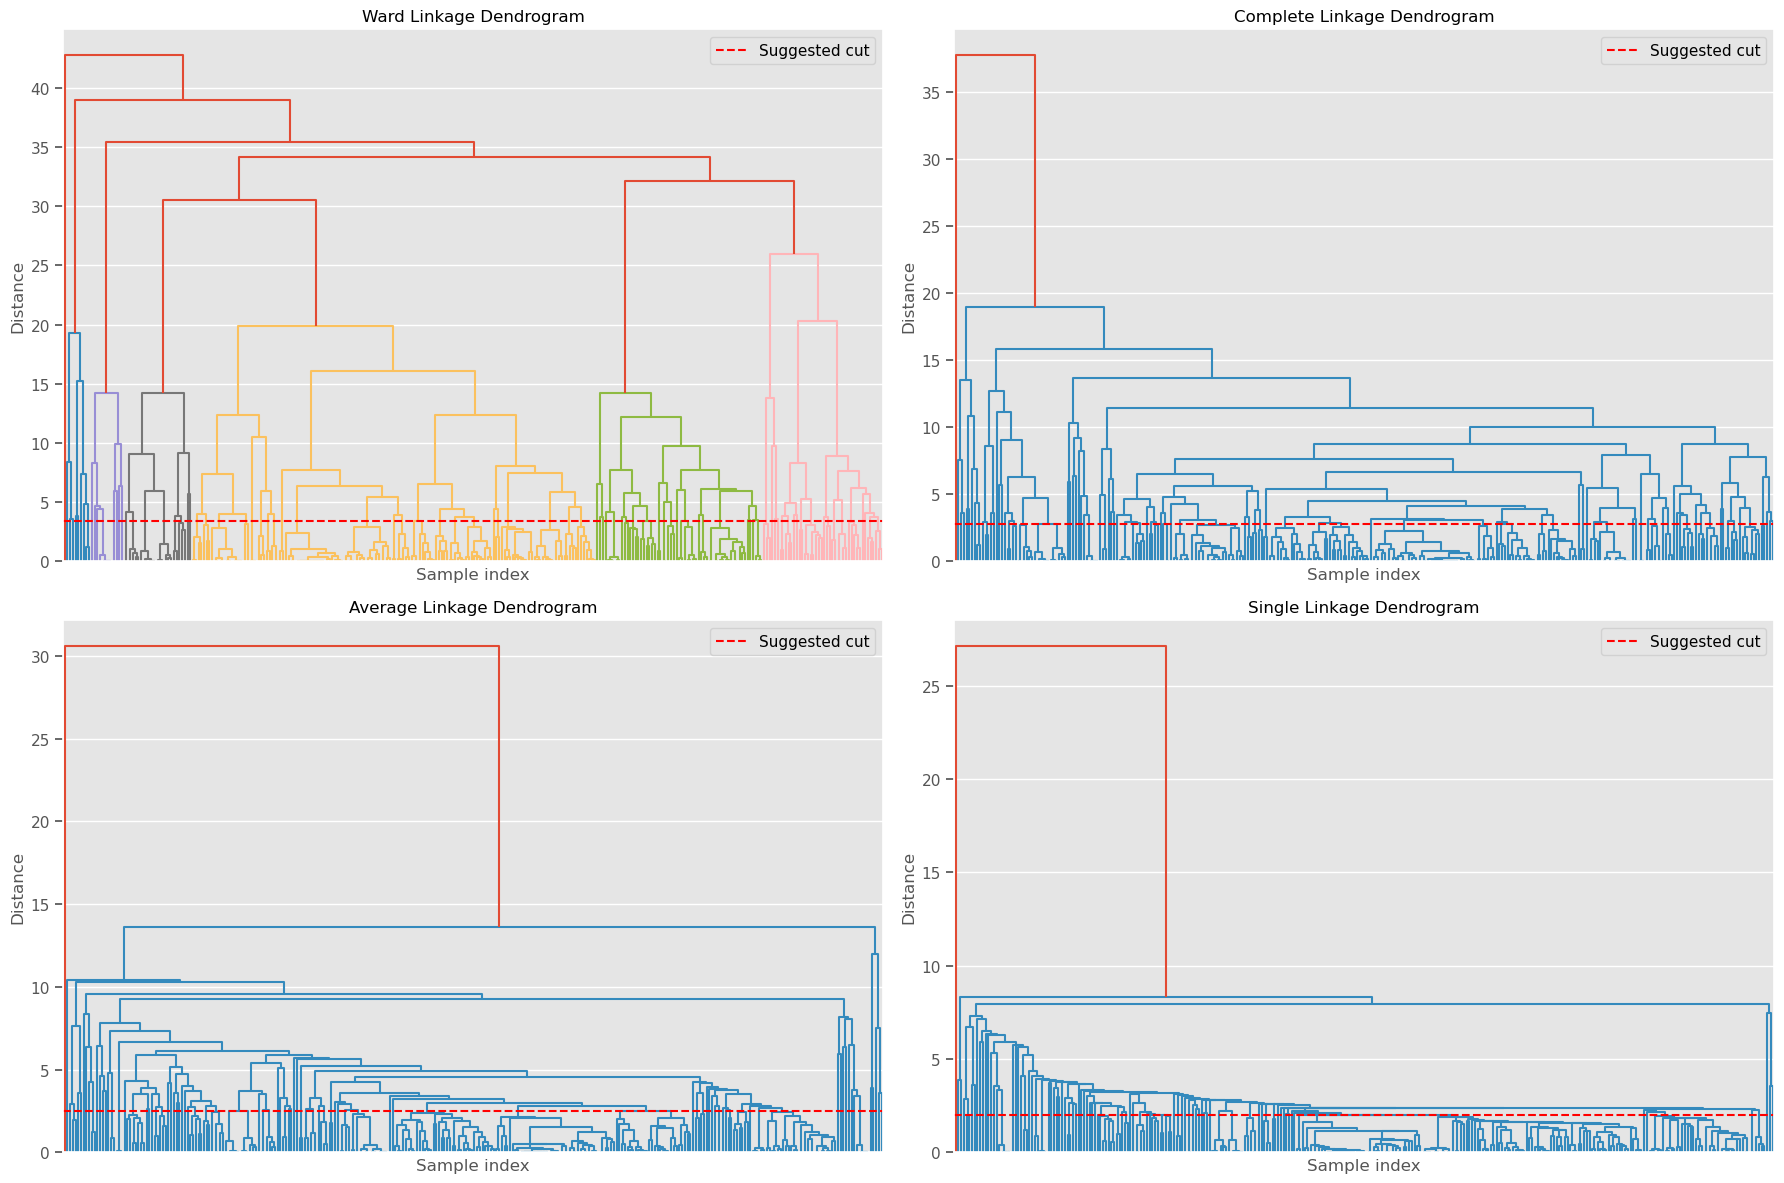

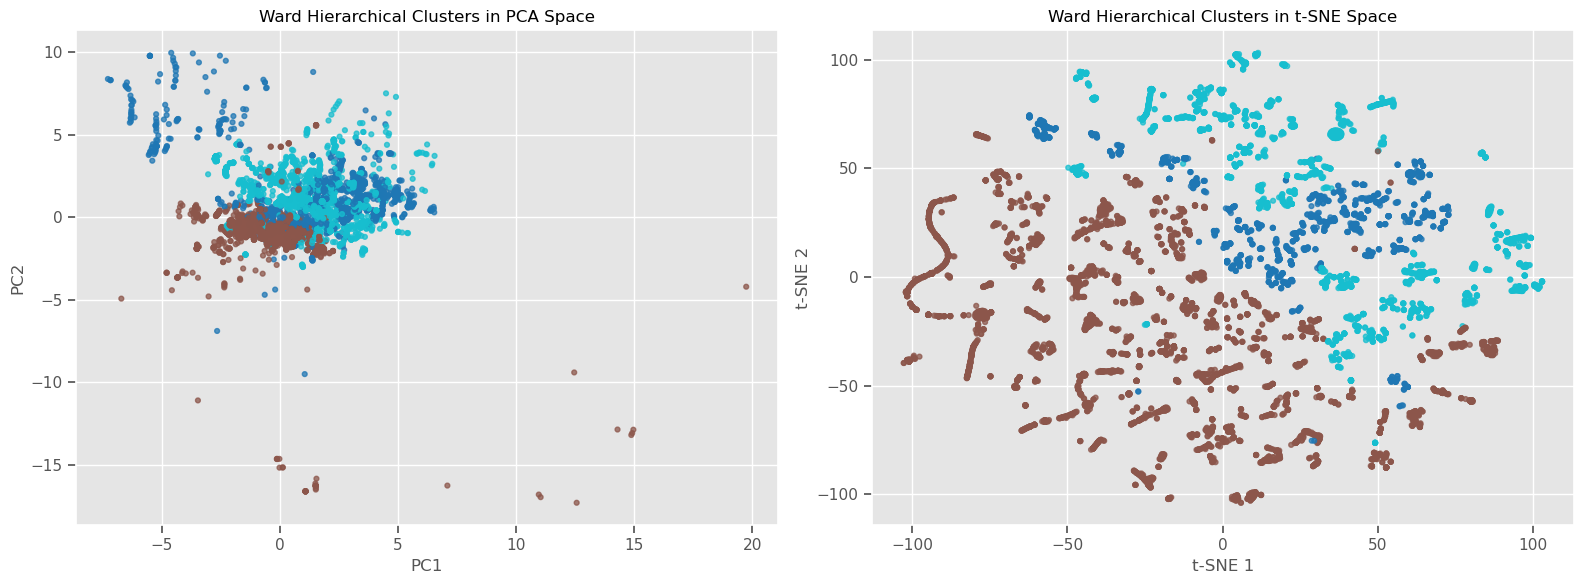

In [ ]:
hier_results = []
for k in range(2, 7):
    agg = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = agg.fit_predict(X_selected)
    hier_results.append({
        "Method": "Ward",
        "k": k,
        "Silhouette": silhouette_score(X_selected, labels),
        "Davies-Bouldin": davies_bouldin_score(X_selected, labels),
    })

hier_results_df = pd.DataFrame(hier_results)
display(hier_results_df)

sample_X = X_selected.sample(n=300, random_state=RANDOM_STATE)
linkage_methods = ["ward", "complete", "average", "single"]

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()
for ax, method in zip(axes, linkage_methods):
    Z = linkage(sample_X, method=method)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
    ax.axhline(np.percentile(Z[:, 2], 70), color="red", linestyle="--", label="Suggested cut")
    ax.set_title(f"{method.title()} Linkage Dendrogram")
    ax.set_xlabel("Sample index")
    ax.set_ylabel("Distance")
    ax.legend()

plt.tight_layout()
plt.savefig(FIG_DIR / "13_dendrograms.png", dpi=150, bbox_inches="tight")
plt.show()

hier_k = 3
ward_model = AgglomerativeClustering(n_clusters=hier_k, linkage="ward")
ward_labels = ward_model.fit_predict(X_selected)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
axes[0].scatter(X_selected_pca2[:, 0], X_selected_pca2[:, 1], c=ward_labels, cmap="tab10", s=12, alpha=0.75)
axes[0].set_title("Ward Hierarchical Clusters in PCA Space")
axes[0].set_xlabel("PC1")
axes[0].set_ylabel("PC2")

axes[1].scatter(X_selected_tsne2[:, 0], X_selected_tsne2[:, 1], c=ward_labels, cmap="tab10", s=12, alpha=0.75)
axes[1].set_title("Ward Hierarchical Clusters in t-SNE Space")
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")

plt.tight_layout()
plt.savefig(FIG_DIR / "14_hier_clusters.png", dpi=150, bbox_inches="tight")
plt.show()


### Q8 Analysis

The optimal cluster count from a dendrogram is chosen by looking for a large vertical jump in linkage distance and cutting before the largest merge. This preserves groups that are internally similar but separated from other groups.

Ward linkage is often the most interpretable here because it minimizes within-cluster variance, which aligns well with standardized numerical chemical features.

PCA gives a broad global view of the clusters, while t-SNE highlights local groupings more clearly. K-Means is faster and easier to compare across `k`, while hierarchical clustering gives a richer view of nested structure.


## Q9 - Regression Problem Definition and Train-Test Split


The regression task is to predict `critical_temp`, the superconducting critical temperature in Kelvin, from the 81 numerical material descriptor features. Regression is appropriate because the output is continuous rather than categorical.


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

split_stats = pd.DataFrame({
    "y_train": y_train.describe(),
    "y_test": y_test.describe(),
})
display(split_stats)


X_train: (8000, 81)
X_test: (2000, 81)
y_train: (8000,)
y_test: (2000,)


,y_train,y_test
count,8000.000000,2000.000000
mean,58.950142,57.274569
std,31.440010,31.340464
min,0.001000,0.001000
25%,30.000000,29.037500
50%,62.200000,60.000000
75%,85.000000,84.625000
max,143.000000,135.000000


### Q9 Analysis

An 80/20 split is implemented as it leaves enough data for training while preserving a meaningful holdout set for evaluation. A very small test set gives noisy performance estimates whereas a very large test set can starve the model of training data.

The split must be performed before supervised preprocessing that learns from the data. Imputers, scalers, feature selectors and PCA used for supervised modelling should be fit on `X_train` only and then applied to `X_test`.

Representativeness is checked by comparing descriptive statistics of `y_train` and `y_test`. Similar means, medians and ranges suggest the split is reasonable.


## Q10 - Multiple Regression Model Comparison


,Model,R2,MAE,MSE,RMSE
0,Extra Trees,0.850846,7.783813,146.429648,12.100812
1,Random Forest,0.847167,8.150027,150.041110,12.249127
2,Gradient Boosting,0.753819,11.792896,241.684194,15.546195
3,Decision Tree,0.745472,10.792638,249.878321,15.807540
4,Ridge Regression,0.609527,15.513648,383.340826,19.579092
5,Linear Regression,0.609517,15.471615,383.350015,19.579326
6,Lasso Regression,0.582861,16.203228,409.519618,20.236591


Best model by R2: Extra Trees


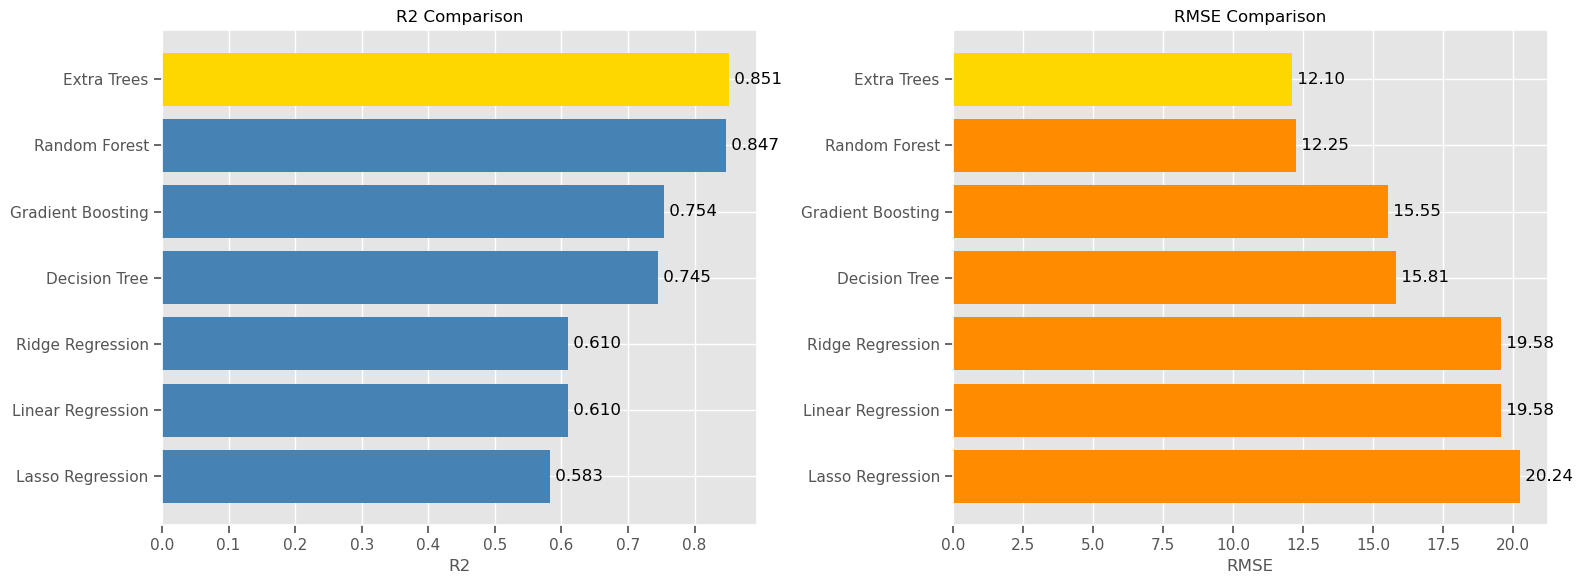

In [ ]:
models = {
    "Linear Regression": LinearRegression(),
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1, max_iter=5000),
    "Decision Tree": DecisionTreeRegressor(max_depth=10, random_state=RANDOM_STATE),
    "Random Forest": RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Extra Trees": ExtraTreesRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1),
    "Gradient Boosting": GradientBoostingRegressor(n_estimators=100, random_state=RANDOM_STATE),
}

model_results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
        ("scaler", StandardScaler()),
        ("model", model),
    ])
    pipe.fit(X_train, y_train)
    preds = pipe.predict(X_test)
    mse = mean_squared_error(y_test, preds)
    model_results.append({
        "Model": name,
        "R2": r2_score(y_test, preds),
        "MAE": mean_absolute_error(y_test, preds),
        "MSE": mse,
        "RMSE": np.sqrt(mse),
    })
    fitted_models[name] = pipe

model_results_df = pd.DataFrame(model_results).sort_values("R2", ascending=False).reset_index(drop=True)
display(model_results_df)

best_model_name = model_results_df.loc[0, "Model"]
print("Best model by R2:", best_model_name)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
plot_df = model_results_df.sort_values("R2")
r2_colors = ["gold" if m == best_model_name else "steelblue" for m in plot_df["Model"]]
axes[0].barh(plot_df["Model"], plot_df["R2"], color=r2_colors)
axes[0].set_title("R2 Comparison")
axes[0].set_xlabel("R2")
for i, v in enumerate(plot_df["R2"]):
    axes[0].text(v, i, f" {v:.3f}", va="center")

rmse_df = model_results_df.sort_values("RMSE", ascending=False)
rmse_best = rmse_df.loc[rmse_df["RMSE"].idxmin(), "Model"]
rmse_colors = ["gold" if m == rmse_best else "darkorange" for m in rmse_df["Model"]]
axes[1].barh(rmse_df["Model"], rmse_df["RMSE"], color=rmse_colors)
axes[1].set_title("RMSE Comparison")
axes[1].set_xlabel("RMSE")
for i, v in enumerate(rmse_df["RMSE"]):
    axes[1].text(v, i, f" {v:.2f}", va="center")

plt.tight_layout()
plt.savefig(FIG_DIR / "16_model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()


### Q10 Analysis

The best model and their metrics are depicted in the above comparison table. Tree-based ensemble models usually perform better on this dataset because the relationship between chemical descriptors and critical temperature is nonlinear and includes feature interactions.

A single Decision Tree is more prone to overfitting because it can partition the training data too specifically. Ensembles such as Random Forest and Extra Trees reduce variance by averaging many trees.

Linear Regression, Ridge and Lasso have higher bias because they model mostly linear relationships. Decision Trees have low bias but high variance. Random Forest and Extra Trees reduce variance through bagging/randomization. Gradient Boosting builds trees sequentially and can reduce bias, but may need tuning.

The `log1p` transformation applied to the positive feature values reduces skewness and compresses extreme feature scales, helping models learn more stable patterns.


## Q11 - PCA + RandomForest Pipeline


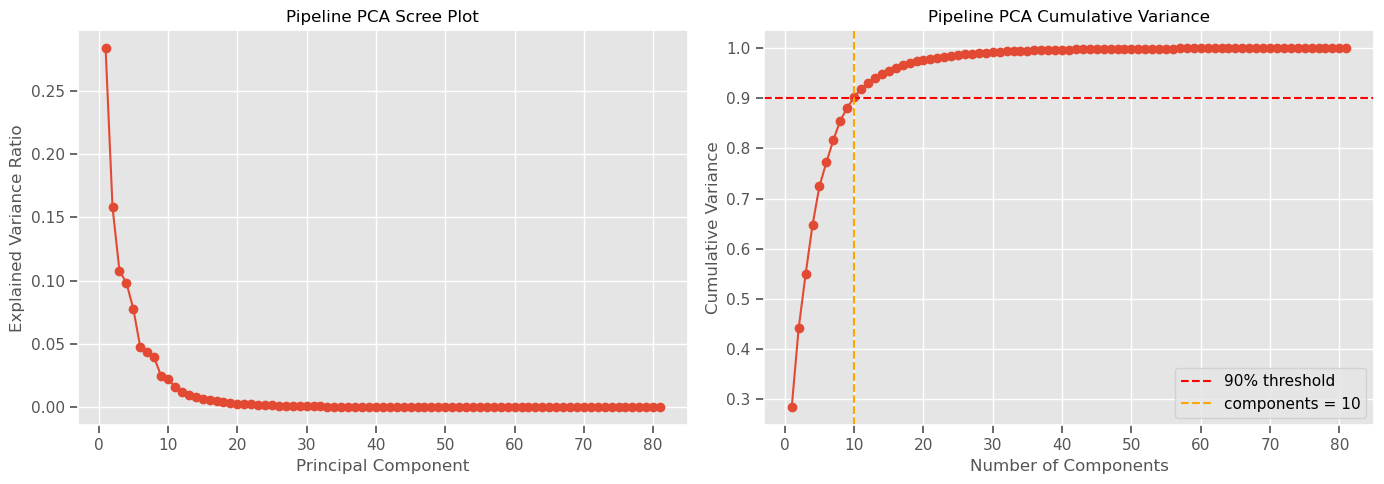

PCA + RandomForest R2: 0.8074588242317675
PCA + RandomForest RMSE: 13.748605038210833
Full-feature RandomForest RMSE: 12.249126905185001
RMSE difference, PCA RF - full RF: 1.499478133025832
PCA components retained: 10


In [ ]:
class PCAAnalyzer(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.90, plot=True):
        self.threshold = threshold
        self.plot = plot

    def fit(self, X, y=None):
        self.full_pca_ = PCA(random_state=RANDOM_STATE)
        self.full_pca_.fit(X)
        self.explained_var_ = self.full_pca_.explained_variance_ratio_
        self.cumulative_variance_ = np.cumsum(self.explained_var_)

        self.pca_ = PCA(n_components=self.threshold, random_state=RANDOM_STATE)
        self.pca_.fit(X)

        if self.plot:
            n_components = self.pca_.n_components_
            fig, axes = plt.subplots(1, 2, figsize=(14, 5))
            axes[0].plot(range(1, len(self.explained_var_) + 1), self.explained_var_, marker="o")
            axes[0].set_title("Pipeline PCA Scree Plot")
            axes[0].set_xlabel("Principal Component")
            axes[0].set_ylabel("Explained Variance Ratio")

            axes[1].plot(range(1, len(self.cumulative_variance_) + 1), self.cumulative_variance_, marker="o")
            axes[1].axhline(self.threshold, color="red", linestyle="--", label=f"{self.threshold:.0%} threshold")
            axes[1].axvline(n_components, color="orange", linestyle="--", label=f"components = {n_components}")
            axes[1].set_title("Pipeline PCA Cumulative Variance")
            axes[1].set_xlabel("Number of Components")
            axes[1].set_ylabel("Cumulative Variance")
            axes[1].legend()
            plt.tight_layout()
            plt.show()

        return self

    def transform(self, X):
        return self.pca_.transform(X)


pca_rf_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("log1p", FunctionTransformer(np.log1p, feature_names_out="one-to-one")),
    ("scaler", StandardScaler()),
    ("pca", PCAAnalyzer(threshold=0.90, plot=True)),
    ("rf", RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE, n_jobs=-1)),
])

pca_rf_pipeline.fit(X_train, y_train)
pca_rf_preds = pca_rf_pipeline.predict(X_test)
pca_rf_mse = mean_squared_error(y_test, pca_rf_preds)
pca_rf_rmse = np.sqrt(pca_rf_mse)
pca_rf_r2 = r2_score(y_test, pca_rf_preds)

full_rf_rmse = float(model_results_df.loc[model_results_df["Model"] == "Random Forest", "RMSE"].iloc[0])
rmse_difference = pca_rf_rmse - full_rf_rmse
n_components_pipeline = pca_rf_pipeline.named_steps["pca"].pca_.n_components_

print("PCA + RandomForest R2:", pca_rf_r2)
print("PCA + RandomForest RMSE:", pca_rf_rmse)
print("Full-feature RandomForest RMSE:", full_rf_rmse)
print("RMSE difference, PCA RF - full RF:", rmse_difference)
print("PCA components retained:", n_components_pipeline)


### Q11 Analysis

The number of PCA components retained inside the pipeline is depicted above. It may differ slightly from above in Part A because this PCA is fit only on the training set after the train/test split, which is the correct supervised workflow.

If the PCA + RandomForest RMSE is higher than the full-feature Random Forest RMSE, PCA is not beneficial for this tree-based model. PCA rotates the original features into linear combinations, which can remove feature-level thresholds and interactions that trees naturally exploit.

Models that benefit most from PCA are distance-based or linear models, such as KNN, linear regression variants, logistic regression, SVMs and models sensitive to multicollinearity.

## Q12 - Final Report and Conclusions

### Part A - Feature Engineering and Clustering

The EDA shows a fully numerical dataset with no missing values, one duplicate row and a right-skewed target distribution. Many features are skewed and strongly correlated because the 81 descriptors are structured summaries of related elemental properties.

VIF-based feature selection is effective for reducing multicollinearity. It removes highly redundant descriptors and leaves a smaller set of features with VIF values below the threshold. This is especially useful before clustering because redundant variables can distort distance-based grouping.

PCA is more useful for global variance structure and dimensionality reduction, while t-SNE is more informative for local visual cluster structure. PCA has interpretable variance percentages; t-SNE provides better exploratory separation but its axes are not physically interpretable.

K-Means gives a simple quantitative clustering baseline across multiple values of `k`. Hierarchical clustering provides a dendrogram-based view of nested relationships, with Ward linkage generally giving the most interpretable structure for standardized numerical features.

The clusters likely represent broad material regimes rather than exact named families. Without chemical formula metadata, labels such as conventional superconductors, cuprate-like high-temperature materials or other specialized families should be treated as hypotheses.

### Part B - Regression Modelling

The regression comparison table ranks all seven models by R2. The best model should be selected based on high R2 and low RMSE. In this dataset, ensemble tree models are expected to outperform linear models because superconducting critical temperature depends on nonlinear combinations of chemical descriptors.

Including PCA before Random Forest may reduce dimensionality, but it can also hurt performance because trees split naturally on original features. PCA is often more helpful for linear and distance-based models than for tree ensembles.

The single preprocessing step with the greatest positive impact is likely scaling for PCA/K-Means and `log1p` feature transformation for regression stability. For deployment in a materials lab, the best-performing ensemble model from the comparison table is the strongest candidate because it balances accuracy and robustness on nonlinear tabular data.
